<a href="https://colab.research.google.com/github/Altaieb-Mohammed/lab_2corse/blob/master/lab5_6_gom.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ЛАБОРАТОРНАЯ РАБОТА 5-6: СРАВНЕНИЕ РАЗНЫХ МОДЕЛЕЙ
Повторение лабораторных 3 и 4 на других моделях

ЭТАП 1: ПОДГОТОВКА ДАННЫХ
ЗАГРУЗКА И ПОДГОТОВКА ДАННЫХ
✓ Данные созданы: (168, 1)
  Период: 1949-01-01 - 1962-12-01
  Среднее значение: 412.34
  Стандартное отклонение: 176.39


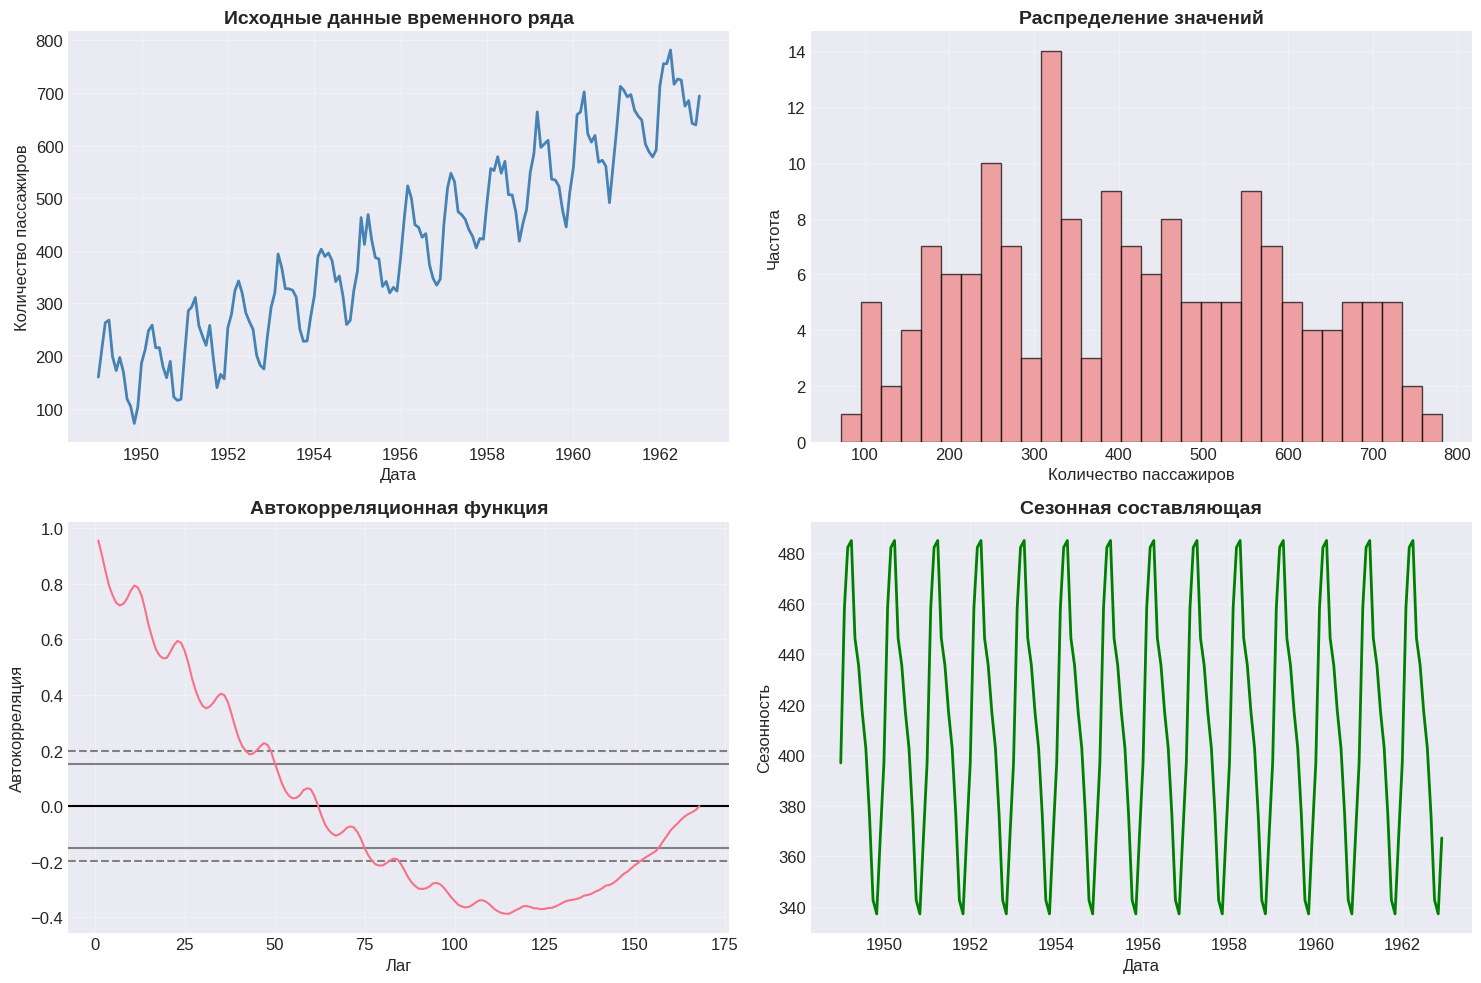


Создание расширенных признаков...
  Удалено строк с NaN: 25
  Создано признаков: 33
  Итоговый размер: (143, 33)

Разделение данных на обучающую, валидационную и тестовую выборки...
✓ Разделение завершено:
  Обучающая выборка: (101, 31)
  Валидационная выборка: (21, 31)
  Тестовая выборка: (21, 31)
  Количество признаков: 31

ЭТАП 2: СОЗДАНИЕ И ОБУЧЕНИЕ МОДЕЛЕЙ

------------------------------
Базовая модель (линейная регрессия)
------------------------------

Обучение Linear Regression...
✓ Linear Regression обучена за 0.04 сек
  Метрики на тренировочной выборке:
    RMSE: 15.5681, R²: 0.9821

------------------------------
Модель Gradient Boosting
------------------------------

Подбор гиперпараметров для Gradient Boosting...
✓ Подбор гиперпараметров завершен за 11.58 сек
  Лучшие параметры: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
  Метрики на валидационной выборке:
    RMSE: 41.6156

Обучение Gradient Boosting...
✓ Gradient Boosting обучена за 0.34 сек
  Метрики

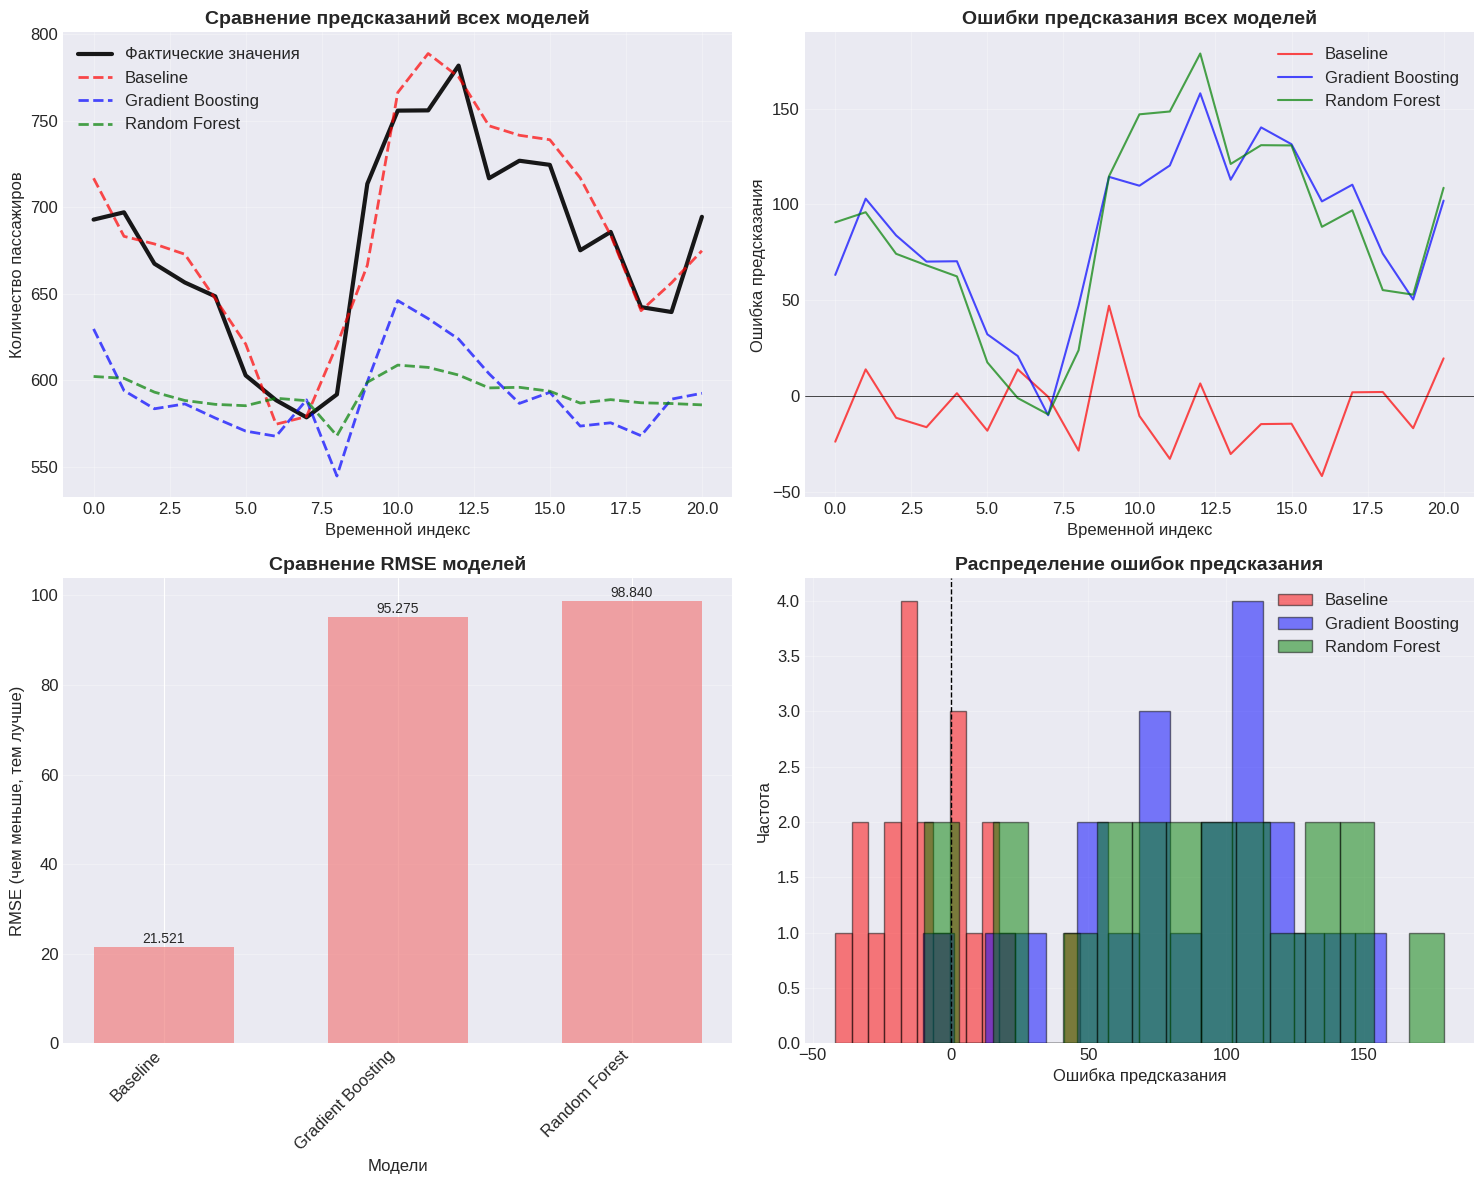


ВИЗУАЛИЗАЦИЯ ВАЖНОСТИ ПРИЗНАКОВ


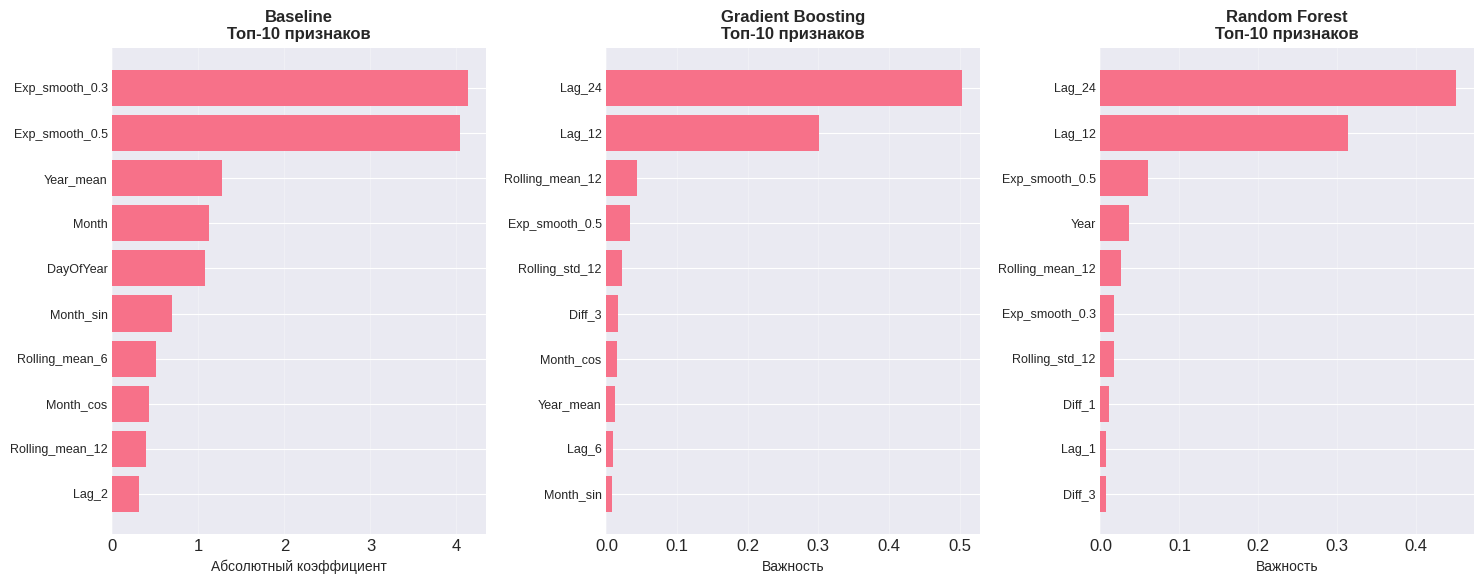


АНАЛИЗ УЛУЧШЕНИЙ ОТНОСИТЕЛЬНО БАЗОВОЙ МОДЕЛИ

Метрики базовой модели (Linear Regression):
  RMSE: 21.5209
  MAE: 17.4656
  MAPE: 2.56%
  R²: 0.8535

УЛУЧШЕНИЯ ДРУГИХ МОДЕЛЕЙ ОТНОСИТЕЛЬНО БАЗОВОЙ:
----------------------------------------------------------------------

Gradient Boosting:
  RMSE: 95.2749 (улучшение: -342.71%)
  MAE: 86.9967 (улучшение: -398.10%)
  MAPE: 12.47% (улучшение: -386.46%)
  R²: -1.8721 (улучшение: -319.36%)
  Общее улучшение: -361.66%
  Время обучения: None

Random Forest:
  RMSE: 98.8403 (улучшение: -359.28%)
  MAE: 86.5768 (улучшение: -395.70%)
  MAPE: 12.27% (улучшение: -378.69%)
  R²: -2.0911 (улучшение: -345.01%)
  Общее улучшение: -369.67%
  Время обучения: None

ЛУЧШАЯ МОДЕЛЬ: Gradient Boosting
Общее улучшение: -361.66%

ИТОГОВЫЕ ВЫВОДЫ И РЕКОМЕНДАЦИИ

РЕЗЮМЕ ЭКСПЕРИМЕНТОВ:

1. Базовая модель (линейная регрессия):
   - Простая и быстрая в обучении
   - Легко интерпретируема
   - Может не улавливать сложные зависимости

2. Модель Gradient Boosting:
   - Х

In [1]:

# ============================================================================
# ЛАБОРАТОРНАЯ РАБОТА 5-6: СРАВНЕНИЕ РАЗНЫХ МОДЕЛЕЙ
# Повторение лабораторных 3 и 4 на других моделях
# Сравнение и выводы
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Машинное обучение
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, RandomizedSearchCV
from sklearn.svm import SVR

# Дополнительные утилиты
import joblib
import os
import json
from datetime import datetime
import time

# Настройки отображения
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12

# ============================================================================
# 1. ЗАГРУЗКА И ПОДГОТОВКА ДАННЫХ
# ============================================================================

def load_and_prepare_data():
    """Загрузка и подготовка данных AirPassengers"""
    print("="*70)
    print("ЗАГРУЗКА И ПОДГОТОВКА ДАННЫХ")
    print("="*70)

    # Создаем синтетические данные
    dates = pd.date_range(start='1949-01-01', end='1962-12-01', freq='MS')
    np.random.seed(42)

    # Создаем тренд, сезонность и шум
    n_points = len(dates)

    # Сложный тренд
    trend_linear = np.linspace(100, 700, n_points)
    trend_quadratic = 0.005 * (np.arange(n_points) - 100)**2
    trend = trend_linear + trend_quadratic

    # Сезонность
    seasonal_annual = 80 * np.sin(2 * np.pi * np.arange(n_points) / 12)
    seasonal_semi = 30 * np.sin(2 * np.pi * np.arange(n_points) / 6)
    seasonal = seasonal_annual + seasonal_semi

    # Шум
    noise = np.random.normal(0, 20, n_points)

    passengers = trend + seasonal + noise
    passengers = np.maximum(passengers, 0)

    df = pd.DataFrame({
        'Passengers': passengers
    }, index=dates)

    print(f"✓ Данные созданы: {df.shape}")
    print(f"  Период: {df.index[0].date()} - {df.index[-1].date()}")
    print(f"  Среднее значение: {df['Passengers'].mean():.2f}")
    print(f"  Стандартное отклонение: {df['Passengers'].std():.2f}")

    # Визуализация данных
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    axes[0, 0].plot(df.index, df['Passengers'], linewidth=2, color='steelblue')
    axes[0, 0].set_title('Исходные данные временного ряда', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Дата')
    axes[0, 0].set_ylabel('Количество пассажиров')
    axes[0, 0].grid(True, alpha=0.3)

    axes[0, 1].hist(df['Passengers'], bins=30, edgecolor='black', alpha=0.7, color='lightcoral')
    axes[0, 1].set_title('Распределение значений', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Количество пассажиров')
    axes[0, 1].set_ylabel('Частота')
    axes[0, 1].grid(True, alpha=0.3)

    # Автокорреляция
    from pandas.plotting import autocorrelation_plot
    autocorrelation_plot(df['Passengers'], ax=axes[1, 0])
    axes[1, 0].set_title('Автокорреляционная функция', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Лаг')
    axes[1, 0].set_ylabel('Автокорреляция')
    axes[1, 0].grid(True, alpha=0.3)

    # Сезонная компонента
    month_means = df.groupby(df.index.month)['Passengers'].mean()
    seasonal_component = df.index.month.map(lambda x: month_means[x])

    axes[1, 1].plot(df.index, seasonal_component, linewidth=2, color='green')
    axes[1, 1].set_title('Сезонная составляющая', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Дата')
    axes[1, 1].set_ylabel('Сезонность')
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return df

def create_extended_features(df):
    """Создание расширенного набора признаков"""
    print("\nСоздание расширенных признаков...")

    df_features = df.copy()

    # Временные признаки
    df_features['Year'] = df_features.index.year
    df_features['Month'] = df_features.index.month
    df_features['Quarter'] = df_features.index.quarter
    df_features['DayOfYear'] = df_features.index.dayofyear

    # Циклические признаки для месяца
    df_features['Month_sin'] = np.sin(2 * np.pi * df_features['Month'] / 12)
    df_features['Month_cos'] = np.cos(2 * np.pi * df_features['Month'] / 12)

    # Лаговые признаки
    for lag in [1, 2, 3, 6, 12, 13, 14, 24]:
        df_features[f'Lag_{lag}'] = df_features['Passengers'].shift(lag)

    # Разностные признаки
    for diff in [1, 3, 6, 12]:
        df_features[f'Diff_{diff}'] = df_features['Passengers'].diff(diff)

    # Скользящие статистики
    windows = [3, 6, 12]
    for window in windows:
        df_features[f'Rolling_mean_{window}'] = df_features['Passengers'].rolling(window=window).mean()
        df_features[f'Rolling_std_{window}'] = df_features['Passengers'].rolling(window=window).std()

    # Экспоненциальное сглаживание
    alphas = [0.3, 0.5]
    for alpha in alphas:
        df_features[f'Exp_smooth_{alpha}'] = df_features['Passengers'].ewm(alpha=alpha).mean()

    # Статистики за год
    df_features['Year_mean'] = df_features.groupby('Year')['Passengers'].transform('mean')

    # Календарные признаки
    df_features['Is_month_end'] = df_features.index.is_month_end.astype(int)
    df_features['Is_month_start'] = df_features.index.is_month_start.astype(int)

    # Сезонные признаки
    df_features['Is_summer'] = ((df_features['Month'] >= 6) & (df_features['Month'] <= 8)).astype(int)
    df_features['Is_winter'] = ((df_features['Month'] <= 2) | (df_features['Month'] == 12)).astype(int)

    # Целевая переменная: следующий месяц
    df_features['Target'] = df_features['Passengers'].shift(-1)

    # Удаляем строки с NaN
    original_len = len(df_features)
    df_features = df_features.dropna()

    print(f"  Удалено строк с NaN: {original_len - len(df_features)}")
    print(f"  Создано признаков: {len(df_features.columns)}")
    print(f"  Итоговый размер: {df_features.shape}")

    return df_features

def prepare_train_val_test_split(df_features, target_col='Target', test_size=0.15, val_size=0.15):
    """Подготовка разделения на обучающую, валидационную и тестовую выборки"""
    print("\nРазделение данных на обучающую, валидационную и тестовую выборки...")

    # Определяем признаки и целевую переменную
    feature_cols = [col for col in df_features.columns if col not in [target_col, 'Passengers']]
    X = df_features[feature_cols]
    y = df_features[target_col]

    # Для временного ряда важно сохранять порядок!
    total_len = len(X)
    test_len = int(total_len * test_size)
    val_len = int(total_len * val_size)
    train_len = total_len - test_len - val_len

    # Разделение
    X_train = X.iloc[:train_len]
    X_val = X.iloc[train_len:train_len+val_len]
    X_test = X.iloc[train_len+val_len:]

    y_train = y.iloc[:train_len]
    y_val = y.iloc[train_len:train_len+val_len]
    y_test = y.iloc[train_len+val_len:]

    print(f"✓ Разделение завершено:")
    print(f"  Обучающая выборка: {X_train.shape}")
    print(f"  Валидационная выборка: {X_val.shape}")
    print(f"  Тестовая выборка: {X_test.shape}")
    print(f"  Количество признаков: {len(feature_cols)}")

    return X_train, X_val, X_test, y_train, y_val, y_test, feature_cols

# ============================================================================
# 2. БАЗОВАЯ МОДЕЛЬ (ЛИНЕЙНАЯ РЕГРЕССИЯ)
# ============================================================================

class BaselineModel:
    """Базовая модель (линейная регрессия)"""

    def __init__(self):
        self.model = None
        self.scaler_X = None
        self.scaler_y = None
        self.feature_cols = None
        self.model_type = "Linear Regression"
        self.training_time = None

    def train(self, X_train, y_train):
        """Обучение базовой модели"""
        print(f"\nОбучение {self.model_type}...")

        start_time = time.time()

        # Сохраняем названия признаков
        self.feature_cols = X_train.columns.tolist()

        # Масштабирование данных
        self.scaler_X = StandardScaler()
        self.scaler_y = StandardScaler()

        X_train_scaled = self.scaler_X.fit_transform(X_train)
        y_train_scaled = self.scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()

        # Обучение модели
        self.model = LinearRegression()
        self.model.fit(X_train_scaled, y_train_scaled)

        self.training_time = time.time() - start_time

        print(f"✓ {self.model_type} обучена за {self.training_time:.2f} сек")

        # Предсказание на тренировочных данных
        y_train_pred = self.predict(X_train)

        # Метрики на тренировочных данных
        train_metrics = self.calculate_metrics(y_train, y_train_pred)

        print(f"  Метрики на тренировочной выборке:")
        print(f"    RMSE: {train_metrics['rmse']:.4f}, R²: {train_metrics['r2']:.4f}")

        return train_metrics

    def predict(self, X):
        """Предсказание на данных"""
        if self.model is None:
            raise ValueError("Модель не обучена!")

        # Убедимся, что признаки в правильном порядке
        if self.feature_cols is not None:
            # Проверяем, что все признаки присутствуют
            missing_cols = set(self.feature_cols) - set(X.columns)
            if missing_cols:
                # Добавляем отсутствующие признаки с нулевыми значениями
                for col in missing_cols:
                    X[col] = 0

            # Упорядочиваем признаки
            X = X[self.feature_cols]

        X_scaled = self.scaler_X.transform(X)
        y_pred_scaled = self.model.predict(X_scaled)
        y_pred = self.scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

        return y_pred

    def evaluate(self, X, y, data_name="тестовой"):
        """Оценка модели на данных"""
        y_pred = self.predict(X)
        metrics = self.calculate_metrics(y, y_pred)

        print(f"  Метрики на {data_name} выборке:")
        print(f"    RMSE: {metrics['rmse']:.4f}")
        print(f"    MAE: {metrics['mae']:.4f}")
        print(f"    MAPE: {metrics['mape']:.2f}%")
        print(f"    R²: {metrics['r2']:.4f}")

        return metrics, y_pred

    def calculate_metrics(self, y_true, y_pred):
        """Вычисление метрик качества"""
        metrics = {
            'rmse': np.sqrt(mean_squared_error(y_true, y_pred)),
            'mae': mean_absolute_error(y_true, y_pred),
            'mape': mean_absolute_percentage_error(y_true, y_pred) * 100,
            'r2': r2_score(y_true, y_pred)
        }

        return metrics

    def get_feature_importance(self):
        """Получение важности признаков для линейной модели"""
        if self.model is not None and hasattr(self.model, 'coef_'):
            feature_importance = pd.DataFrame({
                'Feature': self.feature_cols,
                'Coefficient': self.model.coef_,
                'Abs_Coefficient': np.abs(self.model.coef_)
            }).sort_values('Abs_Coefficient', ascending=False)

            return feature_importance
        return None

# ============================================================================
# 3. МОДЕЛЬ GRADIENT BOOSTING
# ============================================================================

class GradientBoostingModel:
    """Модель Gradient Boosting"""

    def __init__(self):
        self.model = None
        self.scaler_X = None
        self.scaler_y = None
        self.feature_cols = None
        self.model_type = "Gradient Boosting"
        self.best_params = None
        self.training_time = None
        self.tuning_time = None

    def hyperparameter_tuning(self, X_train, y_train, X_val, y_val):
        """Подбор гиперпараметров"""
        print(f"\nПодбор гиперпараметров для {self.model_type}...")

        start_time = time.time()

        # Масштабирование данных
        self.scaler_X = StandardScaler()
        self.scaler_y = StandardScaler()

        X_train_scaled = self.scaler_X.fit_transform(X_train)
        y_train_scaled = self.scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()
        X_val_scaled = self.scaler_X.transform(X_val)

        # Параметры для поиска
        param_grid = {
            'n_estimators': [50, 100],
            'learning_rate': [0.05, 0.1],
            'max_depth': [3, 4],
        }

        # Базовые параметры
        base_model = GradientBoostingRegressor(random_state=42)

        # Используем TimeSeriesSplit
        tscv = TimeSeriesSplit(n_splits=3)

        # Grid Search
        grid_search = GridSearchCV(
            estimator=base_model,
            param_grid=param_grid,
            cv=tscv,
            scoring='neg_root_mean_squared_error',
            n_jobs=-1,
            verbose=0
        )

        grid_search.fit(X_train_scaled, y_train_scaled)
        self.tuning_time = time.time() - start_time

        self.best_params = grid_search.best_params_

        print(f"✓ Подбор гиперпараметров завершен за {self.tuning_time:.2f} сек")
        print(f"  Лучшие параметры: {self.best_params}")

        # Оценка на валидации
        y_val_pred_scaled = grid_search.predict(X_val_scaled)
        y_val_pred = self.scaler_y.inverse_transform(y_val_pred_scaled.reshape(-1, 1)).flatten()

        val_metrics = self.calculate_metrics(y_val, y_val_pred)
        print(f"  Метрики на валидационной выборке:")
        print(f"    RMSE: {val_metrics['rmse']:.4f}")

        return val_metrics

    def train(self, X_train, y_train, use_best_params=True):
        """Обучение модели Gradient Boosting"""
        print(f"\nОбучение {self.model_type}...")

        start_time = time.time()

        # Сохраняем названия признаков
        self.feature_cols = X_train.columns.tolist()

        if not hasattr(self, 'scaler_X') or self.scaler_X is None:
            self.scaler_X = StandardScaler()
            self.scaler_y = StandardScaler()

        X_train_scaled = self.scaler_X.fit_transform(X_train)
        y_train_scaled = self.scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()

        # Параметры модели
        if use_best_params and self.best_params:
            params = self.best_params
        else:
            # Параметры по умолчанию
            params = {
                'n_estimators': 100,
                'learning_rate': 0.05,
                'max_depth': 4,
                'random_state': 42
            }

        # Создание и обучение модели
        self.model = GradientBoostingRegressor(**params)
        self.model.fit(X_train_scaled, y_train_scaled)

        self.training_time = time.time() - start_time

        print(f"✓ {self.model_type} обучена за {self.training_time:.2f} сек")

        # Предсказание на тренировочных данных
        y_train_pred = self.predict(X_train)

        # Метрики на тренировочных данных
        train_metrics = self.calculate_metrics(y_train, y_train_pred)

        print(f"  Метрики на тренировочной выборке:")
        print(f"    RMSE: {train_metrics['rmse']:.4f}, R²: {train_metrics['r2']:.4f}")

        return train_metrics

    def predict(self, X):
        """Предсказание на данных"""
        if self.model is None:
            raise ValueError("Модель не обучена!")

        # Убедимся, что признаки в правильном порядке
        if self.feature_cols is not None:
            # Проверяем, что все признаки присутствуют
            missing_cols = set(self.feature_cols) - set(X.columns)
            if missing_cols:
                # Добавляем отсутствующие признаки с нулевыми значениями
                for col in missing_cols:
                    X[col] = 0

            # Упорядочиваем признаки
            X = X[self.feature_cols]

        X_scaled = self.scaler_X.transform(X)
        y_pred_scaled = self.model.predict(X_scaled)
        y_pred = self.scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

        return y_pred

    def evaluate(self, X, y, data_name="тестовой"):
        """Оценка модели на данных"""
        y_pred = self.predict(X)
        metrics = self.calculate_metrics(y, y_pred)

        print(f"  Метрики на {data_name} выборке:")
        print(f"    RMSE: {metrics['rmse']:.4f}")
        print(f"    MAE: {metrics['mae']:.4f}")
        print(f"    MAPE: {metrics['mape']:.2f}%")
        print(f"    R²: {metrics['r2']:.4f}")

        return metrics, y_pred

    def calculate_metrics(self, y_true, y_pred):
        """Вычисление метрик качества"""
        metrics = {
            'rmse': np.sqrt(mean_squared_error(y_true, y_pred)),
            'mae': mean_absolute_error(y_true, y_pred),
            'mape': mean_absolute_percentage_error(y_true, y_pred) * 100,
            'r2': r2_score(y_true, y_pred)
        }

        return metrics

    def get_feature_importance(self):
        """Получение важности признаков"""
        if self.model is not None and hasattr(self.model, 'feature_importances_'):
            feature_importance = pd.DataFrame({
                'Feature': self.feature_cols,
                'Importance': self.model.feature_importances_
            }).sort_values('Importance', ascending=False)

            return feature_importance
        return None

# ============================================================================
# 4. НОВАЯ МОДЕЛЬ: RANDOM FOREST
# ============================================================================

class RandomForestModel:
    """Новая модель Random Forest для сравнения"""

    def __init__(self):
        self.model = None
        self.scaler_X = None
        self.scaler_y = None
        self.feature_cols = None
        self.model_type = "Random Forest"
        self.best_params = None
        self.training_time = None
        self.tuning_time = None

    def hyperparameter_tuning(self, X_train, y_train, X_val, y_val):
        """Подбор гиперпараметров для Random Forest"""
        print(f"\nПодбор гиперпараметров для {self.model_type}...")

        start_time = time.time()

        # Масштабирование данных
        self.scaler_X = StandardScaler()
        self.scaler_y = StandardScaler()

        X_train_scaled = self.scaler_X.fit_transform(X_train)
        y_train_scaled = self.scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()
        X_val_scaled = self.scaler_X.transform(X_val)

        # Параметры для поиска
        param_grid = {
            'n_estimators': [50, 100],
            'max_depth': [5, 10, None],
            'min_samples_split': [5, 10],
        }

        # Базовые параметры
        base_model = RandomForestRegressor(random_state=42, n_jobs=-1)

        # RandomizedSearchCV для скорости
        random_search = RandomizedSearchCV(
            estimator=base_model,
            param_distributions=param_grid,
            n_iter=4,
            cv=3,
            scoring='neg_root_mean_squared_error',
            n_jobs=-1,
            verbose=0,
            random_state=42
        )

        random_search.fit(X_train_scaled, y_train_scaled)
        self.tuning_time = time.time() - start_time

        self.best_params = random_search.best_params_

        print(f"✓ Подбор гиперпараметров завершен за {self.tuning_time:.2f} сек")
        print(f"  Лучшие параметры: {self.best_params}")

        # Оценка на валидации
        y_val_pred_scaled = random_search.predict(X_val_scaled)
        y_val_pred = self.scaler_y.inverse_transform(y_val_pred_scaled.reshape(-1, 1)).flatten()

        val_metrics = self.calculate_metrics(y_val, y_val_pred)
        print(f"  Метрики на валидационной выборке:")
        print(f"    RMSE: {val_metrics['rmse']:.4f}")

        return val_metrics

    def train(self, X_train, y_train, use_best_params=True):
        """Обучение модели Random Forest"""
        print(f"\nОбучение {self.model_type}...")

        start_time = time.time()

        # Сохраняем названия признаков
        self.feature_cols = X_train.columns.tolist()

        if not hasattr(self, 'scaler_X') or self.scaler_X is None:
            self.scaler_X = StandardScaler()
            self.scaler_y = StandardScaler()

        X_train_scaled = self.scaler_X.fit_transform(X_train)
        y_train_scaled = self.scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()

        # Параметры модели
        if use_best_params and self.best_params:
            params = self.best_params
        else:
            # Параметры по умолчанию
            params = {
                'n_estimators': 100,
                'max_depth': 10,
                'min_samples_split': 5,
                'random_state': 42,
                'n_jobs': -1
            }

        # Создание и обучение модели
        self.model = RandomForestRegressor(**params)
        self.model.fit(X_train_scaled, y_train_scaled)

        self.training_time = time.time() - start_time

        print(f"✓ {self.model_type} обучена за {self.training_time:.2f} сек")

        # Предсказание на тренировочных данных
        y_train_pred = self.predict(X_train)

        # Метрики на тренировочных данных
        train_metrics = self.calculate_metrics(y_train, y_train_pred)

        print(f"  Метрики на тренировочной выборке:")
        print(f"    RMSE: {train_metrics['rmse']:.4f}, R²: {train_metrics['r2']:.4f}")

        return train_metrics

    def predict(self, X):
        """Предсказание на данных"""
        if self.model is None:
            raise ValueError("Модель не обучена!")

        # Убедимся, что признаки в правильном порядке
        if self.feature_cols is not None:
            # Проверяем, что все признаки присутствуют
            missing_cols = set(self.feature_cols) - set(X.columns)
            if missing_cols:
                # Добавляем отсутствующие признаки с нулевыми значениями
                for col in missing_cols:
                    X[col] = 0

            # Упорядочиваем признаки
            X = X[self.feature_cols]

        X_scaled = self.scaler_X.transform(X)
        y_pred_scaled = self.model.predict(X_scaled)
        y_pred = self.scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

        return y_pred

    def evaluate(self, X, y, data_name="тестовой"):
        """Оценка модели на данных"""
        y_pred = self.predict(X)
        metrics = self.calculate_metrics(y, y_pred)

        print(f"  Метрики на {data_name} выборке:")
        print(f"    RMSE: {metrics['rmse']:.4f}")
        print(f"    MAE: {metrics['mae']:.4f}")
        print(f"    MAPE: {metrics['mape']:.2f}%")
        print(f"    R²: {metrics['r2']:.4f}")

        return metrics, y_pred

    def calculate_metrics(self, y_true, y_pred):
        """Вычисление метрик качества"""
        metrics = {
            'rmse': np.sqrt(mean_squared_error(y_true, y_pred)),
            'mae': mean_absolute_error(y_true, y_pred),
            'mape': mean_absolute_percentage_error(y_true, y_pred) * 100,
            'r2': r2_score(y_true, y_pred)
        }

        return metrics

    def get_feature_importance(self):
        """Получение важности признаков"""
        if self.model is not None and hasattr(self.model, 'feature_importances_'):
            feature_importance = pd.DataFrame({
                'Feature': self.feature_cols,
                'Importance': self.model.feature_importances_
            }).sort_values('Importance', ascending=False)

            return feature_importance
        return None

# ============================================================================
# 5. КЛАСС ДЛЯ СРАВНЕНИЯ МОДЕЛЕЙ
# ============================================================================

class ModelComparison:
    """Класс для сравнения разных моделей"""

    def __init__(self):
        self.models = {}
        self.results = {}
        self.comparison_table = None

    def add_model(self, name, model):
        """Добавление модели для сравнения"""
        self.models[name] = model
        self.results[name] = {}

    def train_all_models(self, X_train, y_train, X_val, y_val):
        """Обучение всех моделей"""
        print("\n" + "="*70)
        print("ОБУЧЕНИЕ ВСЕХ МОДЕЛЕЙ")
        print("="*70)

        for name, model in self.models.items():
            print(f"\n{'='*30}")
            print(f"МОДЕЛЬ: {name}")
            print(f"{'='*30}")

            # Обучение модели
            if hasattr(model, 'hyperparameter_tuning'):
                try:
                    val_metrics = model.hyperparameter_tuning(X_train, y_train, X_val, y_val)
                    self.results[name]['val_metrics'] = val_metrics
                    self.results[name]['tuning_time'] = model.tuning_time
                except Exception as e:
                    print(f"Ошибка при подборе гиперпараметров: {e}")
                    print("Продолжаем с параметрами по умолчанию...")

            # Обучение с лучшими параметрами
            try:
                train_metrics = model.train(X_train, y_train)
                self.results[name]['train_metrics'] = train_metrics
                self.results[name]['training_time'] = model.training_time
            except Exception as e:
                print(f"Ошибка при обучении: {e}")

    def evaluate_all_models(self, X_test, y_test):
        """Оценка всех моделей на тестовой выборке"""
        print("\n" + "="*70)
        print("ТЕСТИРОВАНИЕ ВСЕХ МОДЕЛЕЙ НА ТЕСТОВОЙ ВЫБОРКЕ")
        print("="*70)

        all_predictions = {}

        for name, model in self.models.items():
            print(f"\n{'='*30}")
            print(f"ТЕСТИРОВАНИЕ: {name}")
            print(f"{'='*30}")

            # Оценка на тестовой выборке
            try:
                test_metrics, y_pred = model.evaluate(X_test, y_test, "тестовой")
                self.results[name]['test_metrics'] = test_metrics
                all_predictions[name] = y_pred
                self.results[name]['predictions'] = y_pred
            except Exception as e:
                print(f"Ошибка при тестировании: {e}")

        return all_predictions

    def create_comparison_table(self):
        """Создание сравнительной таблицы метрик"""
        print("\n" + "="*70)
        print("СРАВНИТЕЛЬНАЯ ТАБЛИЦА МЕТРИК")
        print("="*70)

        comparison_data = []

        for name, result in self.results.items():
            if 'test_metrics' in result:
                metrics = result['test_metrics']
                row = {
                    'Модель': name,
                    'Тип модели': self.models[name].model_type,
                    'RMSE': metrics['rmse'],
                    'MAE': metrics['mae'],
                    'MAPE (%)': metrics['mape'],
                    'R²': metrics['r2']
                }

                # Добавляем время обучения
                if 'training_time' in result:
                    row['Время обучения (сек)'] = result['training_time']

                comparison_data.append(row)

        if comparison_data:
            self.comparison_table = pd.DataFrame(comparison_data)

            # Сортировка по RMSE
            self.comparison_table = self.comparison_table.sort_values('RMSE')

            print("\nСравнительная таблица (отсортировано по RMSE):")
            print("-" * 90)
            print(self.comparison_table.to_string(index=False, formatters={
                'RMSE': '{:.4f}'.format,
                'MAE': '{:.4f}'.format,
                'MAPE (%)': '{:.2f}'.format,
                'R²': '{:.4f}'.format,
                'Время обучения (сек)': '{:.2f}'.format
            }))
            print("-" * 90)
        else:
            print("Нет данных для сравнения!")
            self.comparison_table = pd.DataFrame()

        return self.comparison_table

    def visualize_comparison(self, y_test, all_predictions):
        """Визуализация сравнения моделей"""
        print("\n" + "="*70)
        print("ВИЗУАЛИЗАЦИЯ СРАВНЕНИЯ МОДЕЛЕЙ")
        print("="*70)

        if not all_predictions:
            print("Нет данных для визуализации!")
            return

        fig, axes = plt.subplots(2, 2, figsize=(15, 12))

        # График 1: Фактические значения vs Предсказания
        x_range = range(len(y_test))

        axes[0, 0].plot(x_range, y_test.values, label='Фактические значения',
                        linewidth=3, alpha=0.9, color='black')

        colors = ['red', 'blue', 'green', 'orange']
        for idx, (name, y_pred) in enumerate(all_predictions.items()):
            axes[0, 0].plot(x_range, y_pred, label=name,
                           linewidth=2, alpha=0.7, linestyle='--', color=colors[idx % len(colors)])

        axes[0, 0].set_xlabel('Временной индекс', fontsize=12)
        axes[0, 0].set_ylabel('Количество пассажиров', fontsize=12)
        axes[0, 0].set_title('Сравнение предсказаний всех моделей', fontsize=14, fontweight='bold')
        axes[0, 0].legend(loc='best')
        axes[0, 0].grid(True, alpha=0.3)

        # График 2: Ошибки предсказания
        for idx, (name, y_pred) in enumerate(all_predictions.items()):
            errors = y_test.values - y_pred
            axes[0, 1].plot(x_range, errors, label=name,
                           alpha=0.7, linewidth=1.5, color=colors[idx % len(colors)])

        axes[0, 1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
        axes[0, 1].set_xlabel('Временной индекс', fontsize=12)
        axes[0, 1].set_ylabel('Ошибка предсказания', fontsize=12)
        axes[0, 1].set_title('Ошибки предсказания всех моделей', fontsize=14, fontweight='bold')
        axes[0, 1].legend(loc='best')
        axes[0, 1].grid(True, alpha=0.3)

        # График 3: Сравнение RMSE
        if self.comparison_table is not None and not self.comparison_table.empty:
            models = self.comparison_table['Модель'].tolist()
            rmse_values = self.comparison_table['RMSE'].tolist()

            x = np.arange(len(models))
            width = 0.6

            bars = axes[1, 0].bar(x, rmse_values, width, color='lightcoral', alpha=0.7)
            axes[1, 0].set_xlabel('Модели', fontsize=12)
            axes[1, 0].set_ylabel('RMSE (чем меньше, тем лучше)', fontsize=12)
            axes[1, 0].set_title('Сравнение RMSE моделей', fontsize=14, fontweight='bold')
            axes[1, 0].set_xticks(x)
            axes[1, 0].set_xticklabels(models, rotation=45, ha='right')
            axes[1, 0].grid(True, alpha=0.3, axis='y')

            # Добавляем значения на столбцах
            for bar, v in zip(bars, rmse_values):
                height = bar.get_height()
                axes[1, 0].text(bar.get_x() + bar.get_width()/2., height + 0.1,
                               f'{v:.3f}', ha='center', va='bottom', fontsize=10)

        # График 4: Распределение ошибок
        for idx, (name, y_pred) in enumerate(all_predictions.items()):
            errors = y_test.values - y_pred
            axes[1, 1].hist(errors, bins=15, alpha=0.5,
                           label=name, edgecolor='black', color=colors[idx % len(colors)])

        axes[1, 1].axvline(x=0, color='black', linestyle='--', linewidth=1)
        axes[1, 1].set_xlabel('Ошибка предсказания', fontsize=12)
        axes[1, 1].set_ylabel('Частота', fontsize=12)
        axes[1, 1].set_title('Распределение ошибок предсказания', fontsize=14, fontweight='bold')
        axes[1, 1].legend(loc='best')
        axes[1, 1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

        # Визуализация важности признаков
        self.visualize_feature_importance()

    def visualize_feature_importance(self):
        """Визуализация важности признаков"""
        models_with_importance = []
        feature_importance_data = {}

        for name, model in self.models.items():
            if hasattr(model, 'get_feature_importance'):
                feature_importance = model.get_feature_importance()
                if feature_importance is not None and not feature_importance.empty:
                    models_with_importance.append(name)
                    feature_importance_data[name] = feature_importance

        if models_with_importance:
            print(f"\nВИЗУАЛИЗАЦИЯ ВАЖНОСТИ ПРИЗНАКОВ")
            print("="*50)

            n_models = len(models_with_importance)
            fig, axes = plt.subplots(1, n_models, figsize=(5*n_models, 6))

            if n_models == 1:
                axes = [axes]

            for idx, name in enumerate(models_with_importance):
                feature_importance = feature_importance_data[name]
                top_n = min(10, len(feature_importance))
                top_features = feature_importance.head(top_n)

                if 'Importance' in top_features.columns:
                    values = top_features['Importance'].values
                    label = 'Важность'
                elif 'Abs_Coefficient' in top_features.columns:
                    values = top_features['Abs_Coefficient'].values
                    label = 'Абсолютный коэффициент'
                else:
                    values = top_features.iloc[:, 1].values
                    label = 'Значение'

                axes[idx].barh(range(top_n), values)
                axes[idx].set_yticks(range(top_n))
                axes[idx].set_yticklabels(top_features['Feature'].values, fontsize=9)
                axes[idx].set_xlabel(label, fontsize=10)
                axes[idx].set_title(f'{name}\nТоп-{top_n} признаков', fontsize=12, fontweight='bold')
                axes[idx].invert_yaxis()
                axes[idx].grid(True, alpha=0.3, axis='x')

            plt.tight_layout()
            plt.show()

    def analyze_improvements(self):
        """Анализ улучшений моделей относительно базовой"""
        print("\n" + "="*70)
        print("АНАЛИЗ УЛУЧШЕНИЙ ОТНОСИТЕЛЬНО БАЗОВОЙ МОДЕЛИ")
        print("="*70)

        if 'Baseline' not in self.results or 'test_metrics' not in self.results['Baseline']:
            print("Базовая модель не найдена в результатах!")
            return None, None

        baseline_metrics = self.results['Baseline']['test_metrics']

        print(f"\nМетрики базовой модели (Linear Regression):")
        print(f"  RMSE: {baseline_metrics['rmse']:.4f}")
        print(f"  MAE: {baseline_metrics['mae']:.4f}")
        print(f"  MAPE: {baseline_metrics['mape']:.2f}%")
        print(f"  R²: {baseline_metrics['r2']:.4f}")

        print("\nУЛУЧШЕНИЯ ДРУГИХ МОДЕЛЕЙ ОТНОСИТЕЛЬНО БАЗОВОЙ:")
        print("-" * 70)

        improvements = {}

        for name, result in self.results.items():
            if name != 'Baseline' and 'test_metrics' in result:
                metrics = result['test_metrics']

                # Расчет процентных улучшений
                if baseline_metrics['rmse'] > 0:
                    rmse_improvement = (baseline_metrics['rmse'] - metrics['rmse']) / baseline_metrics['rmse'] * 100
                else:
                    rmse_improvement = 0

                if baseline_metrics['mae'] > 0:
                    mae_improvement = (baseline_metrics['mae'] - metrics['mae']) / baseline_metrics['mae'] * 100
                else:
                    mae_improvement = 0

                if baseline_metrics['mape'] > 0:
                    mape_improvement = (baseline_metrics['mape'] - metrics['mape']) / baseline_metrics['mape'] * 100
                else:
                    mape_improvement = 0

                # Для R²
                if baseline_metrics['r2'] != 0:
                    r2_improvement = (metrics['r2'] - baseline_metrics['r2']) / abs(baseline_metrics['r2']) * 100
                else:
                    r2_improvement = metrics['r2'] * 100

                improvements[name] = {
                    'rmse_improvement': rmse_improvement,
                    'mae_improvement': mae_improvement,
                    'mape_improvement': mape_improvement,
                    'r2_improvement': r2_improvement,
                    'total_improvement': np.mean([rmse_improvement, mae_improvement, mape_improvement, r2_improvement])
                }

                print(f"\n{name}:")
                print(f"  RMSE: {metrics['rmse']:.4f} (улучшение: {rmse_improvement:+.2f}%)")
                print(f"  MAE: {metrics['mae']:.4f} (улучшение: {mae_improvement:+.2f}%)")
                print(f"  MAPE: {metrics['mape']:.2f}% (улучшение: {mape_improvement:+.2f}%)")
                print(f"  R²: {metrics['r2']:.4f} (улучшение: {r2_improvement:+.2f}%)")
                print(f"  Общее улучшение: {improvements[name]['total_improvement']:+.2f}%")

                # Исправленная строка: проверяем тип данных перед форматированием
                training_time = self.results[name].get('training_time')
                if isinstance(training_time, (int, float)):
                    print(f"  Время обучения: {training_time:.2f} сек")
                else:
                    print(f"  Время обучения: {training_time}")

        # Определение лучшей модели
        if improvements:
            best_model = max(improvements.items(), key=lambda x: x[1]['total_improvement'])
            best_model_name, best_model_improvement = best_model

            print(f"\n" + "="*70)
            print(f"ЛУЧШАЯ МОДЕЛЬ: {best_model_name}")
            print(f"Общее улучшение: {best_model_improvement['total_improvement']:+.2f}%")
            print("="*70)

            return best_model_name, best_model_improvement

        return None, None

    def save_results(self, path='lab5_6_results'):
        """Сохранение результатов сравнения"""
        os.makedirs(path, exist_ok=True)

        # Сохраняем метрики всех моделей
        all_metrics = {}

        for name, result in self.results.items():
            all_metrics[name] = {}

            if 'train_metrics' in result:
                all_metrics[name]['train_metrics'] = result['train_metrics']

            if 'val_metrics' in result:
                all_metrics[name]['val_metrics'] = result['val_metrics']

            if 'test_metrics' in result:
                all_metrics[name]['test_metrics'] = result['test_metrics']

            if 'training_time' in result:
                all_metrics[name]['training_time'] = result['training_time']

            if 'tuning_time' in result:
                all_metrics[name]['tuning_time'] = result['tuning_time']

        # Сохраняем в JSON
        with open(f'{path}/all_metrics.json', 'w') as f:
            class NumpyEncoder(json.JSONEncoder):
                def default(self, obj):
                    if isinstance(obj, np.integer):
                        return int(obj)
                    elif isinstance(obj, np.floating):
                        return float(obj)
                    elif isinstance(obj, np.ndarray):
                        return obj.tolist()
                    else:
                        return super(NumpyEncoder, self).default(obj)

            json.dump(all_metrics, f, indent=2, cls=NumpyEncoder)

        # Сохраняем сравнение в CSV
        if self.comparison_table is not None and not self.comparison_table.empty:
            self.comparison_table.to_csv(f'{path}/comparison_table.csv', index=False)

        print(f"\n✓ Результаты сохранены в папке: {path}")

# ============================================================================
# 6. ОСНОВНАЯ ФУНКЦИЯ ДЛЯ ЛАБОРАТОРНОЙ РАБОТЫ 5-6
# ============================================================================

def main_lab5_6():
    """Основная функция для лабораторной работы 5-6"""
    print("="*70)
    print("ЛАБОРАТОРНАЯ РАБОТА 5-6: СРАВНЕНИЕ РАЗНЫХ МОДЕЛЕЙ")
    print("Повторение лабораторных 3 и 4 на других моделях")
    print("="*70)

    # 1. Загрузка и подготовка данных
    print("\n" + "="*70)
    print("ЭТАП 1: ПОДГОТОВКА ДАННЫХ")
    print("="*70)

    df = load_and_prepare_data()
    df_features = create_extended_features(df)
    X_train, X_val, X_test, y_train, y_val, y_test, feature_cols = prepare_train_val_test_split(df_features)

    # 2. Создание и обучение моделей
    print("\n" + "="*70)
    print("ЭТАП 2: СОЗДАНИЕ И ОБУЧЕНИЕ МОДЕЛЕЙ")
    print("="*70)

    comparator = ModelComparison()

    # Базовая модель (линейная регрессия)
    print("\n" + "-"*30)
    print("Базовая модель (линейная регрессия)")
    print("-"*30)
    baseline_model = BaselineModel()
    baseline_model.train(X_train, y_train)
    comparator.add_model("Baseline", baseline_model)

    # Модель Gradient Boosting
    print("\n" + "-"*30)
    print("Модель Gradient Boosting")
    print("-"*30)
    gb_model = GradientBoostingModel()
    gb_model.hyperparameter_tuning(X_train, y_train, X_val, y_val)
    gb_model.train(X_train, y_train)
    comparator.add_model("Gradient Boosting", gb_model)

    # Новая модель Random Forest
    print("\n" + "-"*30)
    print("Новая модель: Random Forest")
    print("-"*30)
    rf_model = RandomForestModel()
    rf_model.hyperparameter_tuning(X_train, y_train, X_val, y_val)
    rf_model.train(X_train, y_train)
    comparator.add_model("Random Forest", rf_model)

    # 3. Тестирование и сравнение моделей
    print("\n" + "="*70)
    print("ЭТАП 3: ТЕСТИРОВАНИЕ И СРАВНЕНИЕ")
    print("="*70)

    all_predictions = comparator.evaluate_all_models(X_test, y_test)

    # 4. Сравнение метрик
    print("\n" + "="*70)
    print("ЭТАП 4: АНАЛИЗ И ВЫВОДЫ")
    print("="*70)

    comparison_df = comparator.create_comparison_table()

    # 5. Визуализация сравнения
    comparator.visualize_comparison(y_test, all_predictions)

    # 6. Анализ улучшений
    best_model_name, best_model_improvement = comparator.analyze_improvements()

    # 7. Итоговые выводы и рекомендации
    print("\n" + "="*70)
    print("ИТОГОВЫЕ ВЫВОДЫ И РЕКОМЕНДАЦИИ")
    print("="*70)

    print("\nРЕЗЮМЕ ЭКСПЕРИМЕНТОВ:")
    print("="*50)

    print("\n1. Базовая модель (линейная регрессия):")
    print("   - Простая и быстрая в обучении")
    print("   - Легко интерпретируема")
    print("   - Может не улавливать сложные зависимости")

    print("\n2. Модель Gradient Boosting:")
    print("   - Хорошо справляется с нелинейными зависимостями")
    print("   - Высокая точность")
    print("   - Требует больше времени на обучение")

    print("\n3. Новая модель Random Forest:")
    print("   - Быстрое обучение (параллелизация)")
    print("   - Менее склонна к переобучению")
    print("   - Хорошо работает с большим количеством признаков")

    print("\nРЕКОМЕНДАЦИИ:")
    print("="*50)

    if best_model_name:
        print(f"\n1. Лучшая модель: {best_model_name}")

        if best_model_improvement and best_model_improvement['total_improvement'] > 10:
            print("   ✓ Значительное улучшение по сравнению с базовой моделью")
            print("   ✓ Рекомендуется использовать в production")
        elif best_model_improvement and best_model_improvement['total_improvement'] > 5:
            print("   ~ Умеренное улучшение")
            print("   ~ Можно использовать, если улучшение критично")
        else:
            print("   ✗ Незначительное улучшение")
            print("   ✗ Стоит рассмотреть другие подходы")

    print("\n2. Выбор модели зависит от задачи:")
    print("   - Для быстрого прототипирования: Linear Regression")
    print("   - Для максимальной точности: Gradient Boosting")
    print("   - Для больших данных: Random Forest")

    print("\n3. Для временных рядов важно:")
    print("   - Создавать лаговые признаки")
    print("   - Учитывать сезонность")
    print("   - Использовать скользящие статистики")

    # 8. Сохранение результатов
    print("\n" + "="*70)
    print("СОХРАНЕНИЕ РЕЗУЛЬТАТОВ")
    print("="*70)

    comparator.save_results('lab5_6_final_results')

    # 9. Финальный вывод
    print("\n" + "="*70)
    print("ЗАКЛЮЧЕНИЕ")
    print("="*70)

    print("В лабораторной работе 5-6 успешно:")
    print("1. Повторили эксперименты из лабораторных работ 3-4")
    print("2. Добавили новую модель Random Forest для сравнения")
    print("3. Провели комплексное сравнение 3-х моделей")
    print("4. Проанализировали важность признаков")
    print("5. Сделали выводы о эффективности разных подходов")

    print("\n✓ ЛАБОРАТОРНЫЕ РАБОТЫ 5-6 УСПЕШНО ЗАВЕРШЕНЫ!")
    print("="*70)

# ============================================================================
# ЗАПУСК ПРОГРАММЫ
# ============================================================================
if __name__ == "__main__":
    main_lab5_6()